In [ ]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import itertools
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from dotenv import load_dotenv
from scipy import stats

In [1]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
stim_modality = "visual" # modality of decoded stimuli

NameError: name 'load_dotenv' is not defined

# Classification performance in HC

## Visual predicted stimuli

In [58]:
# Load decoding data from each HC subfield
ROI_list = ["CA1", "CA3", "GC_DG", "subiculum"] #, "HC"]
df_list = []
for ROI in ROI_list:
    df = pd.read_csv(f"{DATA_PATH}/{ROI}_wholeROI_{stim_modality}/balanced_group_data.csv")
    df["subfield"] = ROI
    df_list.append(df)
HCdecoding_df = pd.concat(df_list, ignore_index=True)

CA1 decoding accuracy
auditory runs: 0.51, p = 0.1537, n = 24
visual runs: 0.49, p = 0.9967, n = 24
CA3 decoding accuracy
auditory runs: 0.50, p = 0.8463, n = 24
visual runs: 0.50, p = 0.5806, n = 24
GC_DG decoding accuracy
auditory runs: 0.51, p = 0.1537, n = 24
visual runs: 0.51, p = 0.0758, n = 24
subiculum decoding accuracy
auditory runs: 0.49, p = 0.9242, n = 24
visual runs: 0.50, p = 0.5806, n = 24


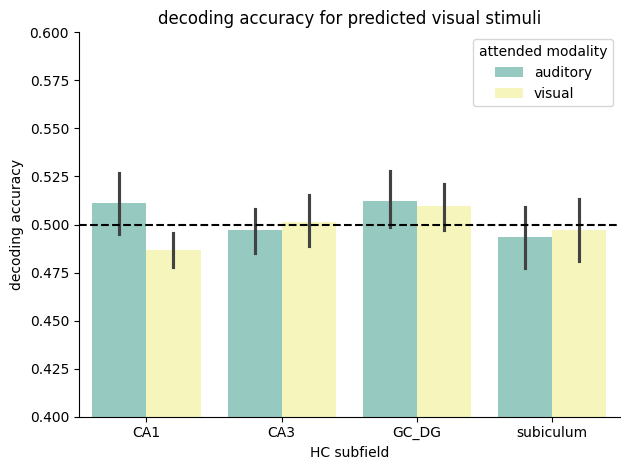

In [ ]:
dat = HCdecoding_df.copy().groupby(["subj", "subfield", "modality"], as_index=0)["correct"].mean().reset_index()
savefig = False
sns.barplot(data=dat, x="subfield", y="correct", hue="modality", palette="Set3", ci=95)
plt.ylabel("decoding accuracy")
plt.xlabel("HC subfield")
plt.title(f"decoding accuracy for predicted {stim_modality} stimuli")
plt.legend(title="attended modality")
plt.ylim(0.4, 0.6)
plt.axhline(y=0.5, color="k", linestyle="--")
sns.despine()
plt.tight_layout()
if savefig:
    plt.savefig(f"figures/HC/{stim_modality}_decoding.svg", dpi=300)
for subfield in dat["subfield"].unique():
    print(f"{subfield} decoding accuracy")
    for modality in dat["modality"].unique():
        dat_subfield_modality = dat[(dat["subfield"] == subfield) & (dat["modality"] == modality)] 
        result = stats.binomtest(sum(dat_subfield_modality["correct"] > 0.5), len(dat_subfield_modality), 0.5, alternative="greater") # bionomial test
        print(f"{modality} runs: {dat_subfield_modality['correct'].mean():.2f}, p = {result.pvalue:.4f}, n = {len(dat_subfield_modality)}")
    

# Modeling classification probabilities in EVC based on predicted stimuli and HC subfields activation

## Load data

In [60]:
ROI = "EVC"
N_VOXELS = "wholeROI"
# The dataframe with all trials will be used to fit regression models with trial by trial measures
# The reason for this is that before fitting we need to aggreggate the data of each trial across permutations
# This can't be done with the balanced data bacause of the random sampling, which leads to non-idential sets of trial indices from each permutation
alltrials_df = pd.read_csv(f"{DATA_PATH}/{ROI}_{N_VOXELS}/group_data.csv") 
alltrials_df = alltrials_df[alltrials_df["subj"] != "sub-22"] # HC subfield data for this subject is not available
            
alltrials_df["correct"] = alltrials_df["correct"].astype(int)
alltrials_df["pred"] = alltrials_df["pred"].astype(str)
alltrials_df["ign_pred"] = alltrials_df["ign_pred"].astype(str)
alltrials_df["v_pred"] = np.where(alltrials_df["modality"] == "visual", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["a_pred"] = np.where(alltrials_df["modality"] == "auditory", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["v_learned"] = alltrials_df["v_learned"].astype(str)
alltrials_df["a_learned"] = alltrials_df["a_learned"].astype(str)
alltrials_df["expected_stim"] = np.where(alltrials_df["expected_stim"] == 0, "CW", "CCW")
alltrials_df["stim"] = np.where(alltrials_df["stim"] == 0, "CW", "CCW")

# Aggregate across perms, while retaining important columns
alltrials_df = alltrials_df.groupby(['subj', 'run', 'trial']).agg(
    correct=('correct', 'mean'), 
    modality=('modality', 'first'),
    v_pred=('v_pred', 'first'),
    a_pred=('a_pred', 'first'),
    v_learned=('v_learned', 'first'),
    a_learned=('a_learned', 'first'),
    classified_stim=('classified_stim', 'mean'),
    stim = ('stim', 'first'),
    expected_stim=('expected_stim', 'first'),
    z_distance=('z_distance', 'mean'),
    decision_distances=('decision_distances', 'mean'),
    prob_0=('prob_0', 'mean'),
    prob_1=('prob_1', 'mean'),
    CA1=('CA1', 'mean'),
    CA3=('CA3', 'mean'),
    GC_DG=('GC_DG', 'mean'),
    subiculum=('subiculum', 'mean'),
    HC=('bilateralHC', 'mean'),
).reset_index()

# Binarize the 'correct' column
alltrials_df['correct'] = alltrials_df['correct'].round()

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

## Model interactions between subfield activity, expected stimulus and explicit knowledge

Tables were 

In [ ]:
alltrials_df["expected_stim"] = alltrials_df["expected_stim"].astype("category")
alltrials_df["stim"] = alltrials_df["stim"].astype("category")
alltrials_df["v_learned"] = alltrials_df["v_learned"].astype("category")
alltrials_df["a_learned"] = alltrials_df["a_learned"].astype("category")
alltrials_df["a_pred"] = alltrials_df["a_pred"].astype("category")

### CA1

In [38]:
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"prob_1 ~ expected_stim * {subfield_ROI} * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                      Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          prob_1
No. Observations:            3456             Method:                      REML  
No. Groups:                  24               Scale:                       0.0084
Min. group size:             144              Log-Likelihood:              inf   
Max. group size:             144              Converged:                   Yes   
Mean group size:             144.0                                               
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                               0.000                                    
expected_stim[T.CW]                     0.019    0.005  4.066 0.000  0.010  0.029
v_learned[T.1]                        

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWar

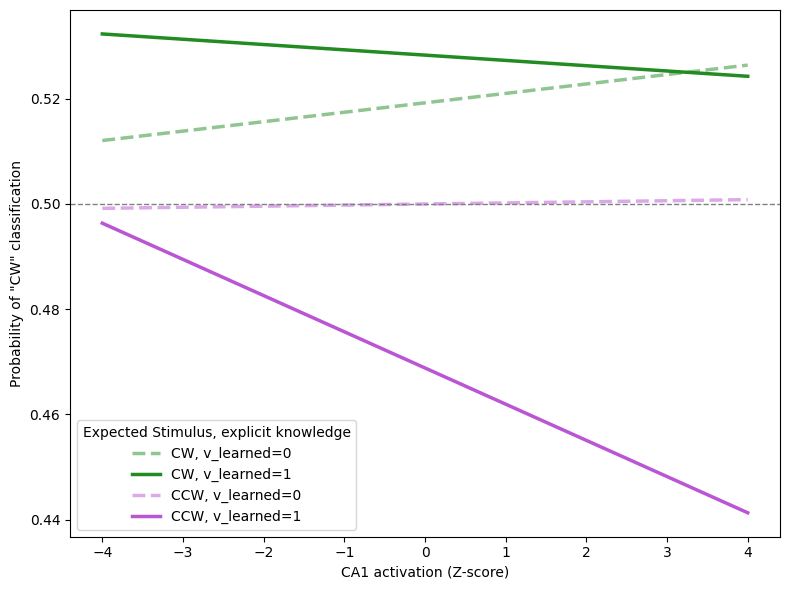

In [39]:
# Artificial dataset
ca1_values = np.linspace(-4, 4, 100)
expected_stim_levels = ["CW", "CCW"]
v_learned_levels = ["0", "1"]

# Generate full combinationof factors
grid = pd.DataFrame(list(itertools.product(expected_stim_levels, v_learned_levels, ca1_values)),
                    columns=["expected_stim", "v_learned", subfield_ROI])

# Ensure categorical levels are encoded like in the model
grid["expected_stim"] = pd.Categorical(grid["expected_stim"], categories=dat["expected_stim"].unique())
grid["v_learned"] = grid["v_learned"].astype(dat["v_learned"].dtype)

# Predict using fixed effects only (no grouping info)
grid["predicted_prob"] = mdf.predict(exog=grid) + 0.5

# Plotting
plt.figure(figsize=(8, 6))
colors = {"CW": "forestgreen", "CCW": "mediumorchid"}

for expected_stim in grid["expected_stim"].unique():
    for v_learned in grid["v_learned"].unique():
        subset = grid[(grid["expected_stim"] == expected_stim) & (grid["v_learned"] == v_learned)]
        linestyle = "--" if v_learned == "0" else "-"
        alpha = 0.5 if v_learned == "0" else 1.0
        label = f"{expected_stim}, v_learned={v_learned}"
        
        sns.lineplot(data=subset, x=subfield_ROI, y="predicted_prob",
                     color=colors[expected_stim], linestyle=linestyle,
                     linewidth=2.5, alpha=alpha, label=label)


plt.ylabel('Probability of "CW" classification')
plt.xlabel(f"{subfield_ROI} activation (Z-score)")
plt.axhline(y=0.5, color="grey", linestyle="--", linewidth=1)
plt.legend(title="Expected Stimulus, explicit knowledge")
plt.tight_layout()
plt.show()


### CA3

In [40]:
subfield_ROI = "CA3"
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"prob_1 ~ expected_stim * {subfield_ROI}", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     prob_1   
No. Observations:     3456        Method:                 REML     
No. Groups:           24          Scale:                  0.0085   
Min. group size:      144         Log-Likelihood:         3306.4229
Max. group size:      144         Converged:              Yes      
Mean group size:      144.0                                        
-------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                0.482    0.002 216.841 0.000  0.478  0.487
expected_stim[T.CW]      0.037    0.003  11.704 0.000  0.031  0.043
CA3                     -0.002    0.002  -1.120 0.263 -0.007  0.002
expected_stim[T.CW]:CA3  0.000    0.003   0.030 0.976 -0.006  0.006
Group Var                0.000    0.000                        

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [41]:
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"prob_1 ~ expected_stim * {subfield_ROI} * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                      Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          prob_1
No. Observations:            3456             Method:                      REML  
No. Groups:                  24               Scale:                       0.0084
Min. group size:             144              Log-Likelihood:              inf   
Max. group size:             144              Converged:                   Yes   
Mean group size:             144.0                                               
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                               0.000                                    
expected_stim[T.CW]                     0.019    0.005  4.077 0.000  0.010  0.029
v_learned[T.1]                        

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWar

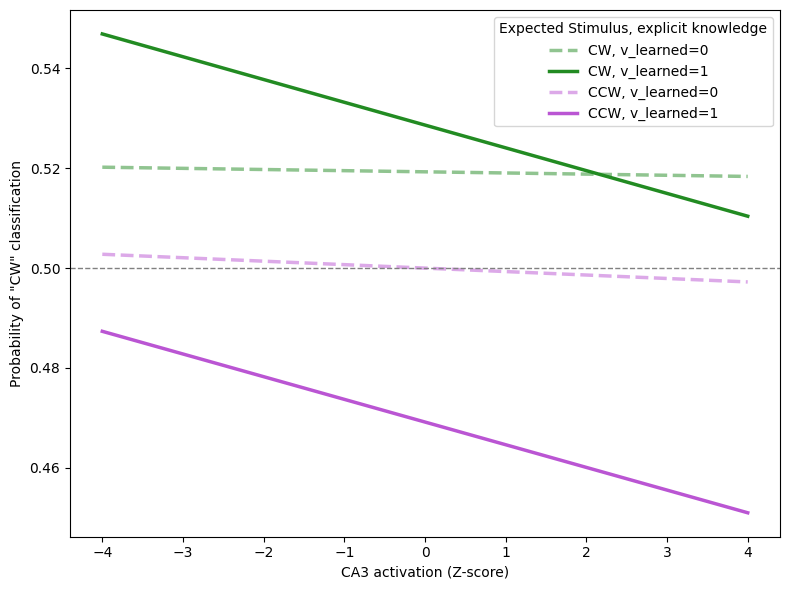

In [42]:
# Artificial dataset
ca1_values = np.linspace(-4, 4, 100)
expected_stim_levels = ["CW", "CCW"]
v_learned_levels = ["0", "1"]

# Generate full combinationof factors
grid = pd.DataFrame(list(itertools.product(expected_stim_levels, v_learned_levels, ca1_values)),
                    columns=["expected_stim", "v_learned", subfield_ROI])

# Ensure categorical levels are encoded like in the model
grid["expected_stim"] = pd.Categorical(grid["expected_stim"], categories=dat["expected_stim"].unique())
grid["v_learned"] = grid["v_learned"].astype(dat["v_learned"].dtype)

# Predict using fixed effects only (no grouping info)
grid["predicted_prob"] = mdf.predict(exog=grid) + 0.5

# Plotting
plt.figure(figsize=(8, 6))
colors = {"CW": "forestgreen", "CCW": "mediumorchid"}

for expected_stim in grid["expected_stim"].unique():
    for v_learned in grid["v_learned"].unique():
        subset = grid[(grid["expected_stim"] == expected_stim) & (grid["v_learned"] == v_learned)]
        linestyle = "--" if v_learned == "0" else "-"
        alpha = 0.5 if v_learned == "0" else 1.0
        label = f"{expected_stim}, v_learned={v_learned}"
        
        sns.lineplot(data=subset, x=subfield_ROI, y="predicted_prob",
                     color=colors[expected_stim], linestyle=linestyle,
                     linewidth=2.5, alpha=alpha, label=label)


plt.ylabel('Probability of "CW" classification')
plt.xlabel(f"{subfield_ROI} activation (Z-score)")
plt.axhline(y=0.5, color="grey", linestyle="--", linewidth=1)
plt.legend(title="Expected Stimulus, explicit knowledge")
plt.tight_layout()
plt.show()


### DG-CG

In [46]:
subfield_ROI = "GC_DG"
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"prob_1 ~ expected_stim * {subfield_ROI}", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     prob_1   
No. Observations:       3456        Method:                 REML     
No. Groups:             24          Scale:                  0.0085   
Min. group size:        144         Log-Likelihood:         3306.2986
Max. group size:        144         Converged:              Yes      
Mean group size:        144.0                                        
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  0.482    0.002 216.781 0.000  0.478  0.487
expected_stim[T.CW]        0.037    0.003  11.716 0.000  0.031  0.043
GC_DG                     -0.002    0.002  -0.903 0.366 -0.006  0.002
expected_stim[T.CW]:GC_DG -0.001    0.003  -0.188 0.851 -0.007  0.006
Group Var                  0.000    

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [47]:
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"prob_1 ~ expected_stim * {subfield_ROI} * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                       Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           prob_1
No. Observations:            3456              Method:                       REML  
No. Groups:                  24                Scale:                        0.0084
Min. group size:             144               Log-Likelihood:               inf   
Max. group size:             144               Converged:                    Yes   
Mean group size:             144.0                                                 
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 0.000                                    
expected_stim[T.CW]                       0.019    0.005  4.098 0.000  0.010  0.029
v_learned[T.1] 

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWar

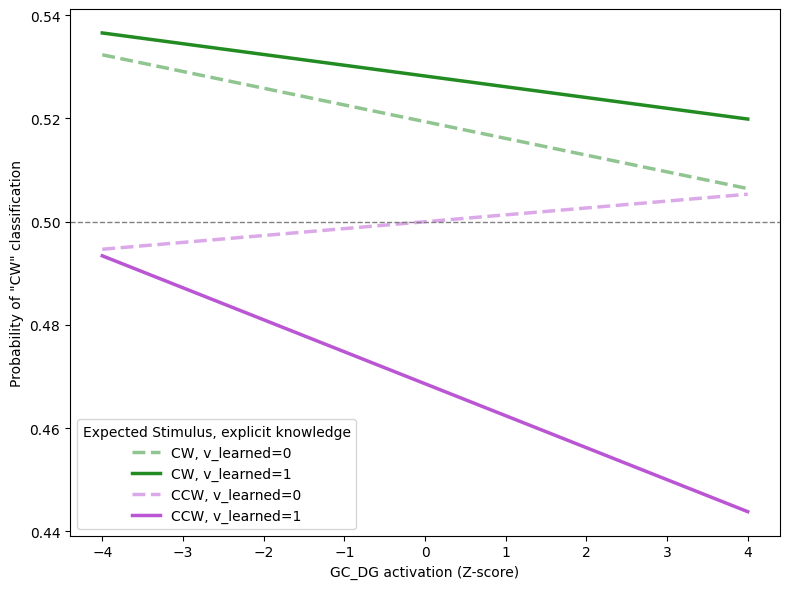

In [48]:
# Artificial dataset
ca1_values = np.linspace(-4, 4, 100)
expected_stim_levels = ["CW", "CCW"]
v_learned_levels = ["0", "1"]

# Generate full combinationof factors
grid = pd.DataFrame(list(itertools.product(expected_stim_levels, v_learned_levels, ca1_values)),
                    columns=["expected_stim", "v_learned", subfield_ROI])

# Ensure categorical levels are encoded like in the model
grid["expected_stim"] = pd.Categorical(grid["expected_stim"], categories=dat["expected_stim"].unique())
grid["v_learned"] = grid["v_learned"].astype(dat["v_learned"].dtype)

# Predict using fixed effects only (no grouping info)
grid["predicted_prob"] = mdf.predict(exog=grid) + 0.5

# Plotting
plt.figure(figsize=(8, 6))
colors = {"CW": "forestgreen", "CCW": "mediumorchid"}

for expected_stim in grid["expected_stim"].unique():
    for v_learned in grid["v_learned"].unique():
        subset = grid[(grid["expected_stim"] == expected_stim) & (grid["v_learned"] == v_learned)]
        linestyle = "--" if v_learned == "0" else "-"
        alpha = 0.5 if v_learned == "0" else 1.0
        label = f"{expected_stim}, v_learned={v_learned}"
        
        sns.lineplot(data=subset, x=subfield_ROI, y="predicted_prob",
                     color=colors[expected_stim], linestyle=linestyle,
                     linewidth=2.5, alpha=alpha, label=label)


plt.ylabel('Probability of "CW" classification')
plt.xlabel(f"{subfield_ROI} activation (Z-score)")
plt.axhline(y=0.5, color="grey", linestyle="--", linewidth=1)
plt.legend(title="Expected Stimulus, explicit knowledge")
plt.tight_layout()
plt.show()


### Subiculum

In [49]:
subfield_ROI = "subiculum"
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"prob_1 ~ expected_stim * {subfield_ROI}", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       prob_1   
No. Observations:       3456          Method:                   REML     
No. Groups:             24            Scale:                    0.0086   
Min. group size:        144           Log-Likelihood:           3305.3456
Max. group size:        144           Converged:                Yes      
Mean group size:        144.0                                            
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      0.482    0.002 216.801 0.000  0.478  0.487
expected_stim[T.CW]            0.037    0.003  11.680 0.000  0.031  0.043
subiculum                     -0.001    0.002  -0.426 0.670 -0.005  0.003
expected_stim[T.CW]:subiculum  0.001    0.003   0.245 0.

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [50]:
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy().reset_index(drop=True)
md = sm.MixedLM.from_formula(f"prob_1 ~ expected_stim * {subfield_ROI} * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                         Mixed Linear Model Regression Results
Model:                         MixedLM            Dependent Variable:            prob_1
No. Observations:              3456               Method:                        REML  
No. Groups:                    24                 Scale:                         0.0084
Min. group size:               144                Log-Likelihood:                inf   
Max. group size:               144                Converged:                     Yes   
Mean group size:               144.0                                                   
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                     0.000                                    
expected_stim[T.CW]                           0.019    0.

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWar

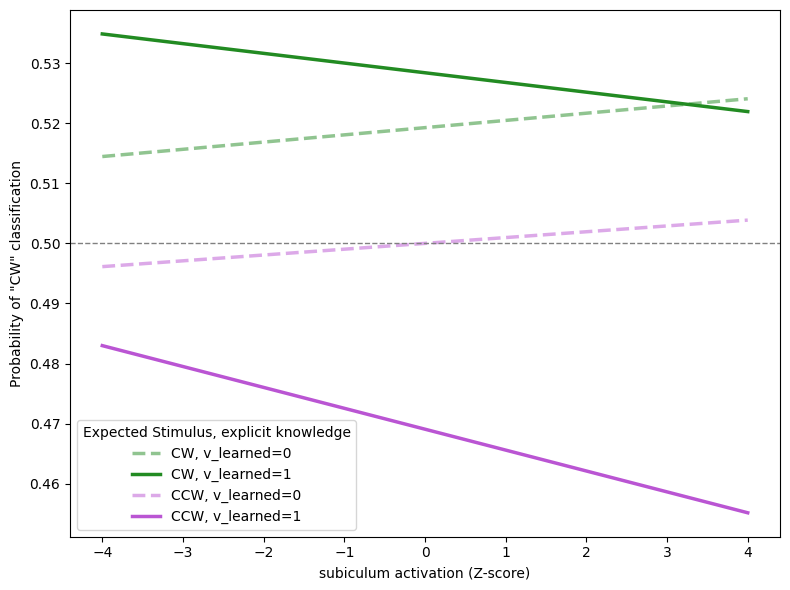

In [51]:
# Artificial dataset
ca1_values = np.linspace(-4, 4, 100)
expected_stim_levels = ["CW", "CCW"]
v_learned_levels = ["0", "1"]

# Generate full combinationof factors
grid = pd.DataFrame(list(itertools.product(expected_stim_levels, v_learned_levels, ca1_values)),
                    columns=["expected_stim", "v_learned", subfield_ROI])

# Ensure categorical levels are encoded like in the model
grid["expected_stim"] = pd.Categorical(grid["expected_stim"], categories=dat["expected_stim"].unique())
grid["v_learned"] = grid["v_learned"].astype(dat["v_learned"].dtype)

# Predict using fixed effects only (no grouping info)
grid["predicted_prob"] = mdf.predict(exog=grid) + 0.5

# Plotting
plt.figure(figsize=(8, 6))
colors = {"CW": "forestgreen", "CCW": "mediumorchid"}

for expected_stim in grid["expected_stim"].unique():
    for v_learned in grid["v_learned"].unique():
        subset = grid[(grid["expected_stim"] == expected_stim) & (grid["v_learned"] == v_learned)]
        linestyle = "--" if v_learned == "0" else "-"
        alpha = 0.5 if v_learned == "0" else 1.0
        label = f"{expected_stim}, v_learned={v_learned}"
        
        sns.lineplot(data=subset, x=subfield_ROI, y="predicted_prob",
                     color=colors[expected_stim], linestyle=linestyle,
                     linewidth=2.5, alpha=alpha, label=label)


plt.ylabel('Probability of "CW" classification')
plt.xlabel(f"{subfield_ROI} activation (Z-score)")
plt.axhline(y=0.5, color="grey", linestyle="--", linewidth=1)
plt.legend(title="Expected Stimulus, explicit knowledge")
plt.tight_layout()
plt.show()
